In [36]:
import pandas as pd
train_data=pd.read_parquet('TrainData/Train.parquet')

In [37]:

train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4504473 entries, 0 to 4504472
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_session       str    
 1   user_id            int64  
 2   day_of_week        int8   
 3   hour_of_day        int8   
 4   total_views        uint32 
 5   total_carts        uint32 
 6   total_removes      uint32 
 7   session_duration   int64  
 8   avg_price          float64
 9   max_price          float64
 10  unique_products    uint32 
 11  unique_brands      uint32 
 12  R_Score            int64  
 13  F_Score            int64  
 14  M_Score            int64  
 15  RFM_Total_Score    int64  
 16  is_purchased       int64  
 17  is_single_brand    int64  
 18  top_brand_encoded  float64
dtypes: float64(3), int64(8), int8(2), str(1), uint32(5)
memory usage: 661.6 MB


Ta chọn mô hình cơ sở là logistics regression

Đang tải dữ liệu...
Kích thước tập X (Đặc trưng): (4504473, 14)
Kích thước tập y (Mục tiêu): (4504473,)

Đang chuẩn hóa dữ liệu (Standardization)...
Đang huấn luyện Logistic Regression... (Có thể mất 1-2 phút)

Đang đưa ra dự đoán trên tập Test...

 BÁO CÁO KẾT QUẢ: LOGISTIC REGRESSION (BASE MODEL) 
              precision    recall  f1-score   support

           0       0.99      0.83      0.91    872934
           1       0.14      0.85      0.24     27961

    accuracy                           0.83    900895
   macro avg       0.57      0.84      0.57    900895
weighted avg       0.97      0.83      0.89    900895

 Điểm ROC-AUC Score: 0.9215



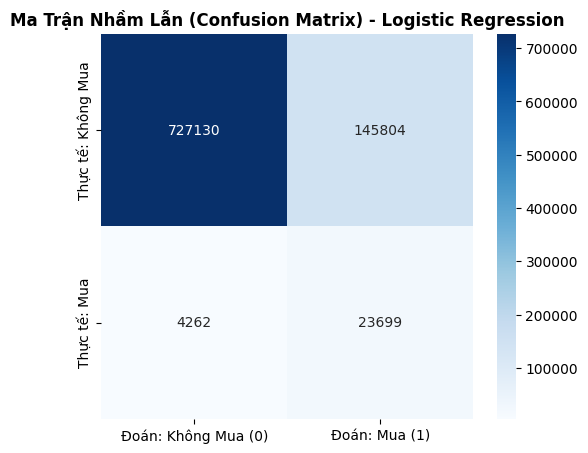

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
print("Đang tải dữ liệu...")
# Lưu ý: Thay đường dẫn nếu bạn lưu file ở chỗ khác
data = pd.read_parquet('TrainData/Train.parquet') 

# Xóa các ID, các cột RFM thô (như đã bàn) VÀ 2 cột giá (theo yêu cầu của bạn)
cols_to_drop = [
    'user_session', 'user_id', 
    'Frequency', 'Monetary', 'Recency', 
    'avg_price', 'max_price' # Đã loại bỏ 2 biến không tuyến tính và đa cộng tuyến
]

# Lọc bỏ các cột này khỏi tập data (dùng errors='ignore' để không báo lỗi nếu cột đã bị xóa từ trước)
df_ml = data.drop(columns=cols_to_drop, errors='ignore')

# Tách Features (X) và Target (y)
X = df_ml.drop(columns=['is_purchased'])
y = df_ml['is_purchased']

print(f"Kích thước tập X (Đặc trưng): {X.shape}")
print(f"Kích thước tập y (Mục tiêu): {y.shape}\n")

# 2. CHIA TẬP TRAIN / TEST (Tỷ lệ 80/20)
# Dùng stratify=y để đảm bảo tỷ lệ khách mua hàng ở tập Train và Test là giống hệt nhau
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. CHUẨN HÓA DỮ LIỆU (Bắt buộc cho Logistic Regression)
print("Đang chuẩn hóa dữ liệu (Standardization)...")
scaler = StandardScaler()

# Chỉ fit trên tập Train để tránh rò rỉ dữ liệu (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. HUẤN LUYỆN MÔ HÌNH (BASE MODEL)
print("Đang huấn luyện Logistic Regression... (Có thể mất 1-2 phút)")
# class_weight='balanced' giúp xử lý việc quá ít người mua hàng
model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# 5. DỰ ĐOÁN VÀ ĐÁNH GIÁ (EVALUATION)
print("\nĐang đưa ra dự đoán trên tập Test...\n")
y_pred = model_lr.predict(X_test_scaled)
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1] # Xác suất khách hàng sẽ mua (0 -> 1)

# In báo cáo kết quả
print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: LOGISTIC REGRESSION (BASE MODEL) ")
print("=====================================================")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f" Điểm ROC-AUC Score: {roc_auc:.4f}")
print("=====================================================\n")

# 6. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Logistic Regression', fontweight='bold')
plt.show()

Đang quét để tìm ngưỡng tối đa hóa MACRO PRECISION...
-> Ngưỡng (Threshold) tối ưu nhất: 0.9900
-> Tại ngưỡng này, Macro Precision dự kiến đạt: 0.6911

 BÁO CÁO KẾT QUẢ VỚI NGƯỠNG TỐI ƯU MACRO PRECISION (0.9900) 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    872934
           1       0.41      0.12      0.19     27961

    accuracy                           0.97    900895
   macro avg       0.69      0.56      0.58    900895
weighted avg       0.95      0.97      0.96    900895



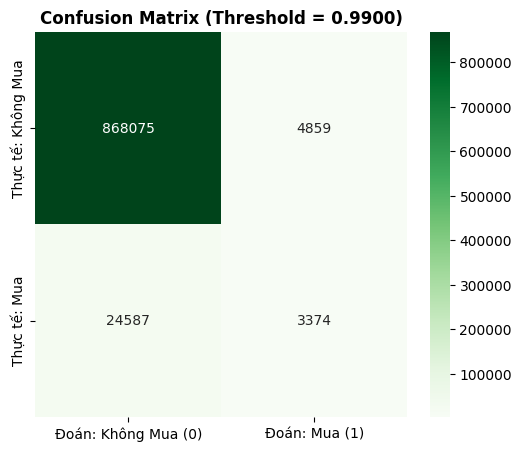

In [9]:
from sklearn.metrics import precision_score
import numpy as np

print("Đang quét để tìm ngưỡng tối đa hóa MACRO PRECISION...")

# 1. Tạo một mảng gồm 100 ngưỡng để thử nghiệm (từ 0.01 đến 0.99)
thresholds_to_test = np.linspace(0.01, 0.99, 100)

best_macro_precision = 0.0
best_threshold = 0.5
expected_recall_macro = 0.0

# 2. Quét qua từng ngưỡng
for t in thresholds_to_test:
    # Dự đoán thử với ngưỡng t
    y_pred_t = (y_prob >= t).astype(int)
    
    # Tính toán Macro Precision (dùng zero_division=0 để tránh lỗi chia cho 0 ở các ngưỡng cực đoan)
    macro_prec = precision_score(y_test, y_pred_t, average='macro', zero_division=0)
    
    # Cập nhật nếu tìm thấy điểm cao hơn
    if macro_prec > best_macro_precision:
        best_macro_precision = macro_prec
        best_threshold = t

print(f"-> Ngưỡng (Threshold) tối ưu nhất: {best_threshold:.4f}")
print(f"-> Tại ngưỡng này, Macro Precision dự kiến đạt: {best_macro_precision:.4f}")

# 3. Áp dụng ngưỡng tốt nhất vào để dự đoán thật
y_pred_best_macro = (y_prob >= best_threshold).astype(int)

# 4. In báo cáo đánh giá cuối cùng
print("\n===================================================================")
print(f" BÁO CÁO KẾT QUẢ VỚI NGƯỠNG TỐI ƯU MACRO PRECISION ({best_threshold:.4f}) ")
print("===================================================================")
# Thêm zero_division=0 vào classification_report cho an toàn
print(classification_report(y_test, y_pred_best_macro, zero_division=0))

# 5. Vẽ lại Confusion Matrix
plt.figure(figsize=(6, 5))
cm_opt = confusion_matrix(y_test, y_pred_best_macro)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.4f})', fontweight='bold')
plt.show()

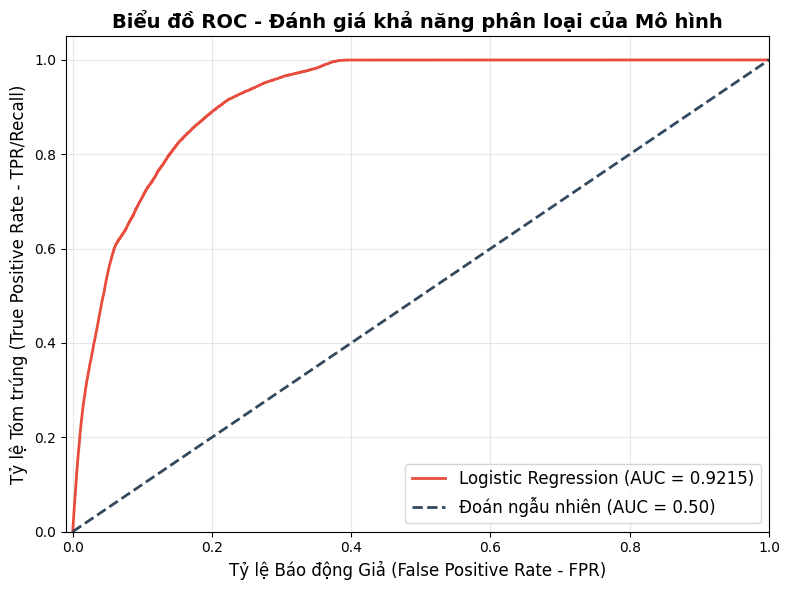

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Tính toán các điểm trên đường cong ROC
# FPR (False Positive Rate) và TPR (True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Lấy lại giá trị AUC đã tính
roc_auc = auc(fpr, tpr)

# 2. Bắt đầu vẽ biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ đường cong ROC của mô hình Logistic Regression (màu đỏ)
plt.plot(fpr, tpr, color='#e74c3c', lw=2, 
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')

# Vẽ đường chéo nét đứt (thể hiện việc đoán mò ngẫu nhiên 50/50)
plt.plot([0, 1], [0, 1], color='#34495e', lw=2, linestyle='--', 
         label='Đoán ngẫu nhiên (AUC = 0.50)')

# Trang trí biểu đồ
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Báo động Giả (False Positive Rate - FPR)', fontsize=12)
plt.ylabel('Tỷ lệ Tóm trúng (True Positive Rate - TPR/Recall)', fontsize=12)
plt.title('Biểu đồ ROC - Đánh giá khả năng phân loại của Mô hình', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# Hiển thị
plt.tight_layout()
plt.show()

In [6]:
import joblib

joblib.dump(model_lr, 'model_logistic_regression.pkl')

['model_logistic_regression.pkl']


Đang dự đoán xác suất trên tập Test...
Đã quét các ngưỡng và tìm thấy điểm tối ưu!
Ngưỡng cắt mới (Threshold): 0.9174
↳ Dự kiến Precision đạt: 0.3000
↳ Dự kiến Recall giữ được: 0.3869

 BÁO CÁO KẾT QUẢ: LOGISTIC REGRESSION (NGƯỠNG 0.9174) 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    872934
           1       0.30      0.39      0.34     27961

    accuracy                           0.95    900895
   macro avg       0.64      0.68      0.66    900895
weighted avg       0.96      0.95      0.96    900895

Điểm ROC-AUC Score: 0.9215



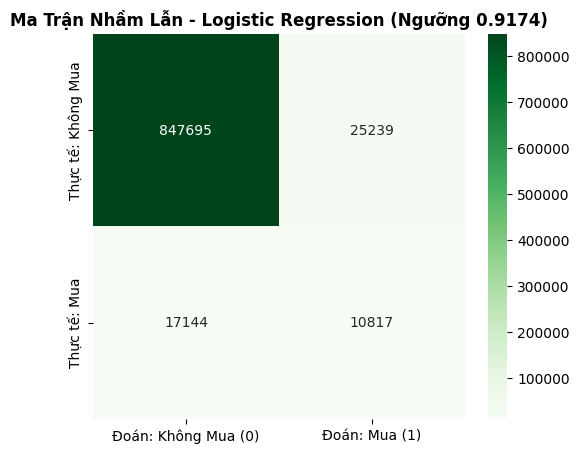

In [39]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, confusion_matrix

# =====================================================================
# 5. DỰ ĐOÁN VÀ TÌM NGƯỠNG TỐI ƯU HÓA PRECISION
# =====================================================================
print("\nĐang dự đoán xác suất trên tập Test...")
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1] # Lấy xác suất khách hàng chốt đơn

# Tính toán mọi kịch bản Precision và Recall ở mọi ngưỡng cắt
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# --- CHIẾN THUẬT TỐI ƯU PRECISION ---
# Do Logistic Regression yếu hơn LightGBM, ta đặt mục tiêu Precision cụ thể (Ví dụ: 30% hoặc 35%)
# Thay vì lấy ngưỡng làm F1 cao nhất, ta ép máy tìm ngưỡng ĐẠT ĐƯỢC Precision mục tiêu
target_precision = 0.30 

# Tìm vị trí đầu tiên mà Precision chạm hoặc vượt qua mục tiêu
target_idx = np.argmax(precisions >= target_precision)
best_threshold = thresholds[target_idx]

print(f"Đã quét các ngưỡng và tìm thấy điểm tối ưu!")
print(f"Ngưỡng cắt mới (Threshold): {best_threshold:.4f}")
print(f"↳ Dự kiến Precision đạt: {precisions[target_idx]:.4f}")
print(f"↳ Dự kiến Recall giữ được: {recalls[target_idx]:.4f}\n")

# Áp dụng ngưỡng mới để ra quyết định (Thay vì dùng hàm .predict() mặc định)
y_pred_tuned = (y_prob >= best_threshold).astype(int)

# =====================================================================
# 6. IN BÁO CÁO VÀ VẼ MA TRẬN NHẦM LẪN MỚI
# =====================================================================
print("=====================================================")
print(f" BÁO CÁO KẾT QUẢ: LOGISTIC REGRESSION (NGƯỠNG {best_threshold:.4f}) ")
print("=====================================================")
print(classification_report(y_test, y_pred_tuned))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"Điểm ROC-AUC Score: {roc_auc:.4f}")
print("=====================================================\n")

# Vẽ lại ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Logistic Regression (Ngưỡng {best_threshold:.4f})', fontweight='bold')
plt.show()

Cây quyết định

✔️ Đã huấn luyện xong!
Đang đưa ra dự đoán trên tập Test...

 BÁO CÁO KẾT QUẢ: DECISION TREE 
              precision    recall  f1-score   support

           0       1.00      0.90      0.94    872934
           1       0.23      0.96      0.37     27961

    accuracy                           0.90    900895
   macro avg       0.61      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895

Điểm ROC-AUC Score: 0.9664



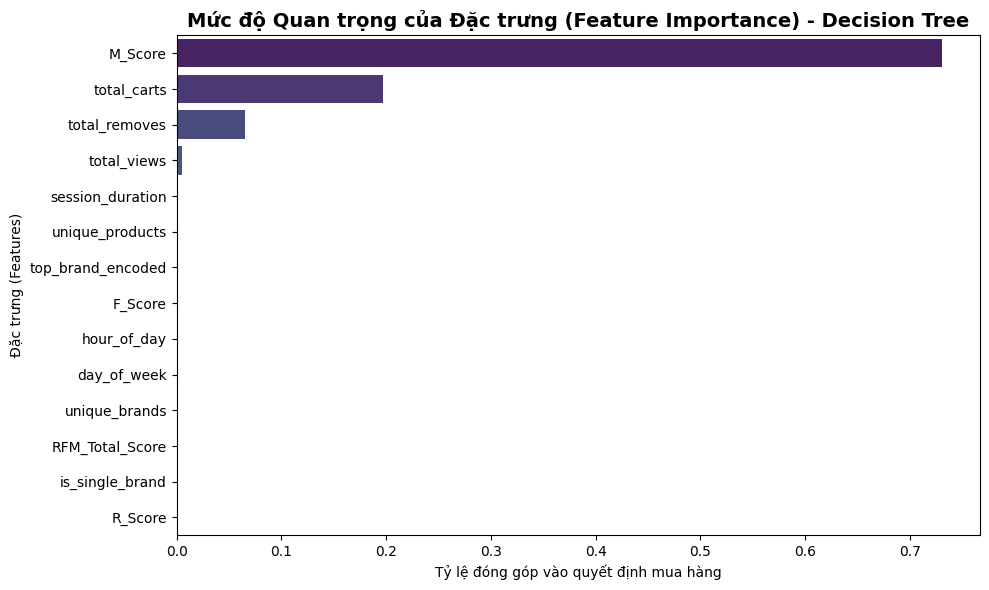

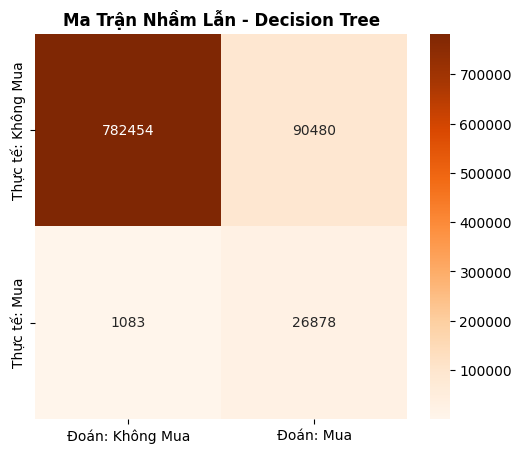

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CÂY QUYẾT ĐỊNH
# Giới hạn độ sâu (max_depth=8) để tránh cây mọc quá sâu gây Overfitting và sập RAM
# Vẫn giữ class_weight='balanced' để trị dứt điểm việc mất cân bằng dữ liệu
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

# Dùng thẳng X_train (chưa chuẩn hóa) để giữ nguyên giá trị thực tế dễ giải thích
model_dt.fit(X_train, y_train)
print("✔️ Đã huấn luyện xong!")

# 2. DỰ ĐOÁN TRÊN TẬP TEST
print("Đang đưa ra dự đoán trên tập Test...\n")
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# 3. BÁO CÁO KẾT QUẢ ĐÁNH GIÁ
print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: DECISION TREE ")
print("=====================================================")
print(classification_report(y_test, y_pred_dt))

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"Điểm ROC-AUC Score: {roc_auc_dt:.4f}")
print("=====================================================\n")

# 4. TRỰC QUAN HÓA: MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)
# Đây là "siêu năng lực" của mô hình Cây, nó sẽ nói cho bạn biết biến nào đóng vai trò chốt đơn lớn nhất
importances = model_dt.feature_importances_
df_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Mức độ Quan trọng của Đặc trưng (Feature Importance) - Decision Tree', fontweight='bold', fontsize=14)
plt.xlabel('Tỷ lệ đóng góp vào quyết định mua hàng')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

# Vẽ Ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Đoán: Không Mua', 'Đoán: Mua'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title('Ma Trận Nhầm Lẫn - Decision Tree', fontweight='bold')
plt.show()

Đã huấn luyện xong Decision Tree!

Đang quét xác suất để tìm ngưỡng tối ưu Precision...
Ngưỡng cắt tối ưu tìm được: 0.8864
↳ Precision đạt: 0.3599
↳ Recall giữ ở mức: 0.6949

 BÁO CÁO KẾT QUẢ: DECISION TREE (NGƯỠNG 0.8864) 
              precision    recall  f1-score   support

           0       0.99      0.96      0.97    872934
           1       0.36      0.69      0.47     27961

    accuracy                           0.95    900895
   macro avg       0.67      0.83      0.72    900895
weighted avg       0.97      0.95      0.96    900895

Điểm ROC-AUC Score: 0.9664



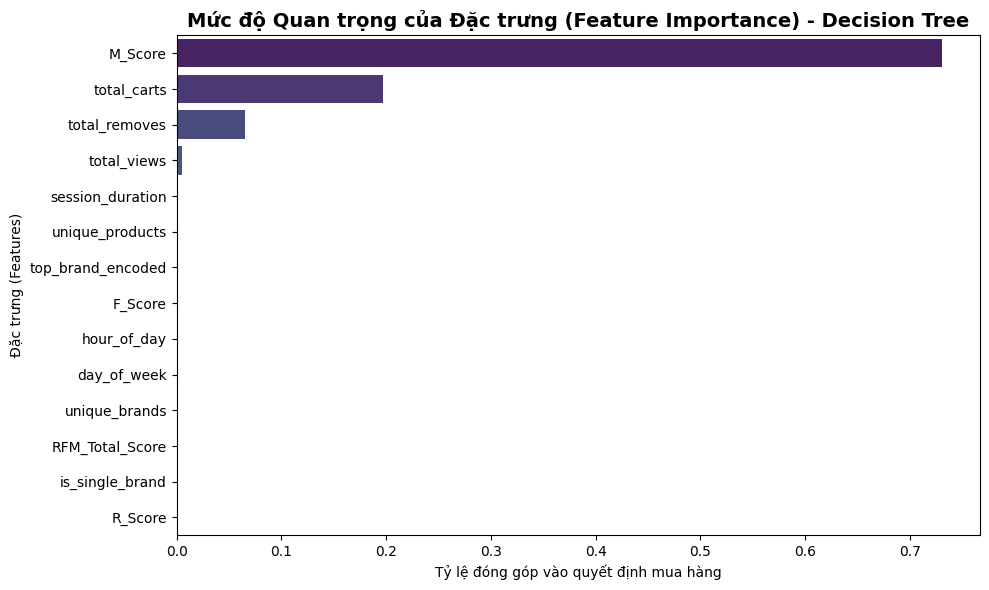

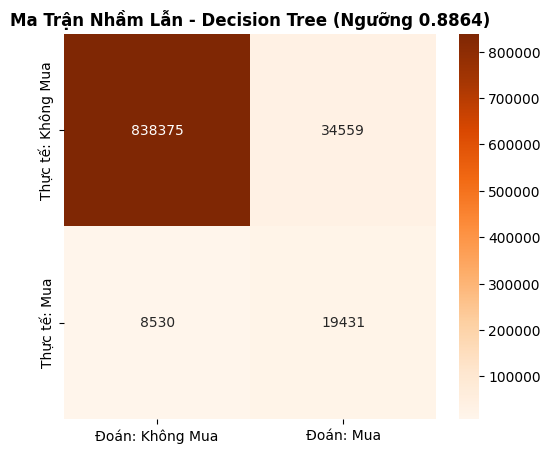

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =====================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CÂY QUYẾT ĐỊNH
# =====================================================================
# Giới hạn độ sâu (max_depth=8) để tránh cây mọc quá sâu gây Overfitting
# Giữ class_weight='balanced' để xử lý mất cân bằng lớp
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

# Dùng X_train gốc (chưa chuẩn hóa)
model_dt.fit(X_train, y_train)
print("Đã huấn luyện xong Decision Tree!")

# =====================================================================
# 2. DỰ ĐOÁN VÀ TÌM NGƯỠNG TỐI ƯU PRECISION
# =====================================================================
print("\nĐang quét xác suất để tìm ngưỡng tối ưu Precision...")
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# Tính toán các điểm Precision, Recall theo từng mức Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_dt)

# Đặt mục tiêu Precision mong muốn (Ví dụ: 35%)
target_precision = 0.35

# Tìm ngưỡng đầu tiên thỏa mãn mức Precision mục tiêu
# Lưu ý: Do Decision Tree trả về xác suất theo bậc, có thể không có điểm chính xác tuyệt đối, 
# ta sẽ lấy điểm gần nhất vượt qua target
valid_indices = np.where(precisions >= target_precision)[0]

if len(valid_indices) > 0:
    target_idx = valid_indices[0]
    best_threshold_dt = thresholds[target_idx] if target_idx < len(thresholds) else thresholds[-1]
else:
    # Nếu không đạt được target, lấy điểm có F1 cao nhất làm phương án dự phòng
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    target_idx = np.argmax(f1_scores)
    best_threshold_dt = thresholds[target_idx]

print(f"Ngưỡng cắt tối ưu tìm được: {best_threshold_dt:.4f}")
print(f"↳ Precision đạt: {precisions[target_idx]:.4f}")
print(f"↳ Recall giữ ở mức: {recalls[target_idx]:.4f}\n")

# Áp dụng ngưỡng mới
y_pred_dt_tuned = (y_prob_dt >= best_threshold_dt).astype(int)

# =====================================================================
# 3. BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (SAU KHI CHỈNH NGƯỠNG)
# =====================================================================
print("=====================================================")
print(f" BÁO CÁO KẾT QUẢ: DECISION TREE (NGƯỠNG {best_threshold_dt:.4f}) ")
print("=====================================================")
print(classification_report(y_test, y_pred_dt_tuned))

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"Điểm ROC-AUC Score: {roc_auc_dt:.4f}")
print("=====================================================\n")

# =====================================================================
# 4. TRỰC QUAN HÓA: MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG
# =====================================================================
importances = model_dt.feature_importances_
df_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Mức độ Quan trọng của Đặc trưng (Feature Importance) - Decision Tree', fontweight='bold', fontsize=14)
plt.xlabel('Tỷ lệ đóng góp vào quyết định mua hàng')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

# =====================================================================
# 5. TRỰC QUAN HÓA: MA TRẬN NHẦM LẪN (DÙNG KẾT QUẢ ĐÃ TINH CHỈNH)
# =====================================================================
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt_tuned)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Đoán: Không Mua', 'Đoán: Mua'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Decision Tree (Ngưỡng {best_threshold_dt:.4f})', fontweight='bold')
plt.show()

Đã huấn luyện xong Decision Tree!

Đang quét xác suất để tìm ngưỡng tối đa hóa F1-Score...
Đã tìm thấy ngưỡng tối ưu!
Ngưỡng cắt (Threshold): 0.9135
↳ F1-Score đạt đỉnh: 0.4755
↳ Precision tương ứng: 0.3790
↳ Recall tương ứng: 0.6382

 BÁO CÁO KẾT QUẢ: DECISION TREE (NGƯỠNG TỐI ƯU F1) 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    872934
           1       0.38      0.64      0.48     27961

    accuracy                           0.96    900895
   macro avg       0.68      0.80      0.73    900895
weighted avg       0.97      0.96      0.96    900895

Điểm ROC-AUC Score: 0.9664



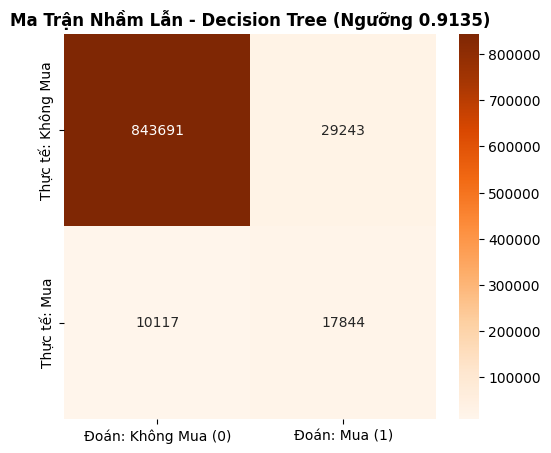

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =====================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CÂY QUYẾT ĐỊNH
# =====================================================================
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
model_dt.fit(X_train, y_train)
print("Đã huấn luyện xong Decision Tree!")

# =====================================================================
# 2. DỰ ĐOÁN VÀ TÌM NGƯỠNG TỐI ƯU F1-SCORE
# =====================================================================
print("\nĐang quét xác suất để tìm ngưỡng tối đa hóa F1-Score...")
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# Tính toán các điểm Precision, Recall theo từng mức Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_dt)

# Tính mảng F1-Score cho tất cả các ngưỡng cắt
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Tìm vị trí có điểm F1 cao nhất
best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print(f"Đã tìm thấy ngưỡng tối ưu!")
print(f"Ngưỡng cắt (Threshold): {best_threshold_f1:.4f}")
print(f"↳ F1-Score đạt đỉnh: {f1_scores[best_idx]:.4f}")
print(f"↳ Precision tương ứng: {precisions[best_idx]:.4f}")
print(f"↳ Recall tương ứng: {recalls[best_idx]:.4f}\n")

# Áp dụng ngưỡng tối ưu F1 vừa tìm được để phân loại nhãn
y_pred_dt_f1 = (y_prob_dt >= best_threshold_f1).astype(int)

# =====================================================================
# 3. BÁO CÁO KẾT QUẢ ĐÁNH GIÁ
# =====================================================================
print("=====================================================")
print(f" BÁO CÁO KẾT QUẢ: DECISION TREE (NGƯỠNG TỐI ƯU F1) ")
print("=====================================================")
print(classification_report(y_test, y_pred_dt_f1))

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"Điểm ROC-AUC Score: {roc_auc_dt:.4f}")
print("=====================================================\n")

# =====================================================================
# 4. TRỰC QUAN HÓA: MA TRẬN NHẦM LẪN
# =====================================================================
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt_f1)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Decision Tree (Ngưỡng {best_threshold_f1:.4f})', fontweight='bold')
plt.show()

Hoan thanh huan luyen mo hinh!
Dang thuc hien du doan tren tap Test...

 BÁO CÁO KẾT QUẢ: DECISION TREE 
              precision    recall  f1-score   support

           0       1.00      0.90      0.94    872934
           1       0.23      0.96      0.37     27961

    accuracy                           0.90    900895
   macro avg       0.61      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895

Diem ROC-AUC Score: 0.9664



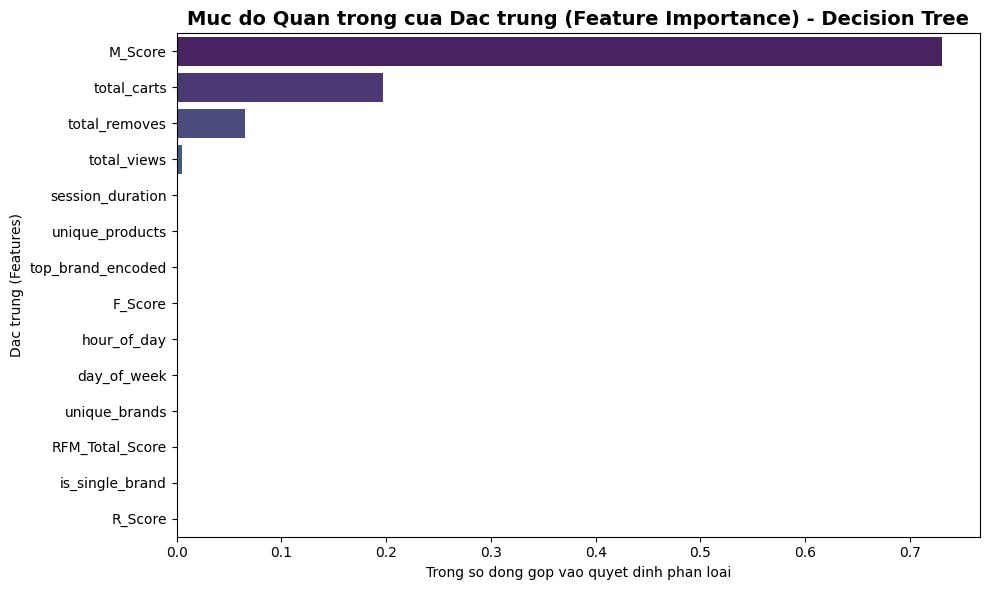

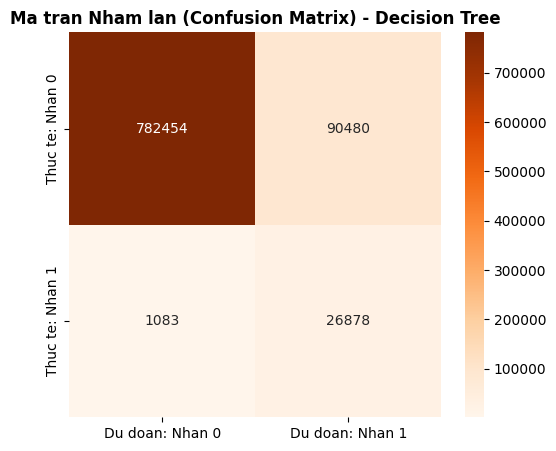

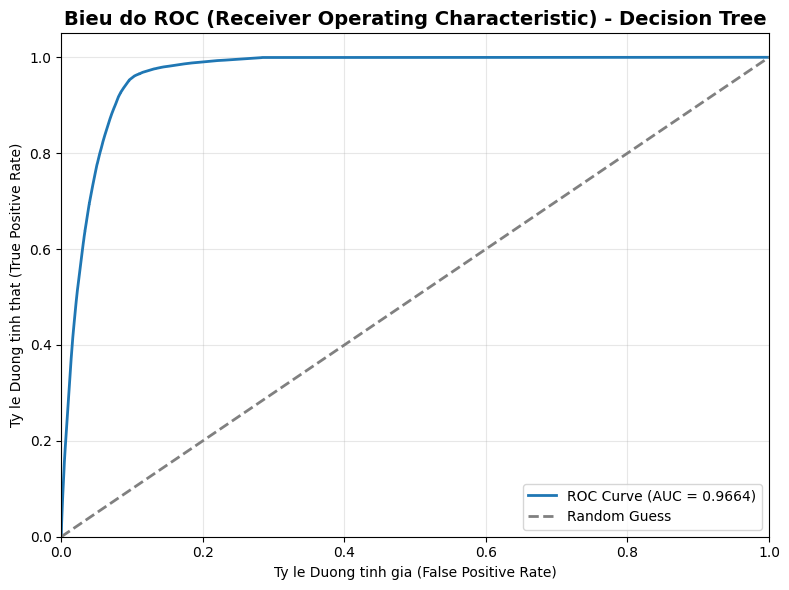

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CÂY QUYẾT ĐỊNH
# Giới hạn độ sâu (max_depth=8) để kiểm soát độ phức tạp, tránh Overfitting
# class_weight='balanced' tự động điều chỉnh trọng số hàm mất mát để xử lý mất cân bằng lớp
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

# Huấn luyện trực tiếp trên tập X_train (Cây quyết định không yêu cầu chuẩn hóa Scaling)
model_dt.fit(X_train, y_train)
print("Hoan thanh huan luyen mo hinh!")

# 2. DỰ ĐOÁN TRÊN TẬP TEST
print("Dang thuc hien du doan tren tap Test...\n")
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1] # Lấy xác suất dự đoán cho Nhãn 1

# 3. BÁO CÁO KẾT QUẢ ĐÁNH GIÁ
print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: DECISION TREE ")
print("=====================================================")
print(classification_report(y_test, y_pred_dt))

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"Diem ROC-AUC Score: {roc_auc_dt:.4f}")
print("=====================================================\n")

# 4. TRỰC QUAN HÓA: MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
importances = model_dt.feature_importances_
df_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Muc do Quan trong cua Dac trung (Feature Importance) - Decision Tree', fontweight='bold', fontsize=14)
plt.xlabel('Trong so dong gop vao quyet dinh phan loai')
plt.ylabel('Dac trung (Features)')
plt.tight_layout()
plt.show()

# 5. TRỰC QUAN HÓA: MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Du doan: Nhan 0', 'Du doan: Nhan 1'],
            yticklabels=['Thuc te: Nhan 0', 'Thuc te: Nhan 1'])
plt.title('Ma tran Nham lan (Confusion Matrix) - Decision Tree', fontweight='bold')
plt.show()

# 6. TRỰC QUAN HÓA: BIỂU ĐỒ ROC (ROC CURVE)
# Tính toán Tỷ lệ Dương tính giả (FPR) và Tỷ lệ Dương tính thật (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))
# Vẽ đường cong ROC
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {roc_auc_dt:.4f})')
# Vẽ đường chéo ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')

# Căn chỉnh biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ty le Duong tinh gia (False Positive Rate)')
plt.ylabel('Ty le Duong tinh that (True Positive Rate)')
plt.title('Bieu do ROC (Receiver Operating Characteristic) - Decision Tree', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Lưu model

In [8]:
import joblib

# Lưu Dictionary này ra file
joblib.dump(model_dt, 'DT_model_bundle.pkl')

['DT_model_bundle.pkl']

Random Forrest

✔️ Trồng rừng xong!
Đang đưa ra dự đoán trên tập Test...

 BÁO CÁO KẾT QUẢ: RANDOM FOREST 
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.23      0.96      0.37     27961

    accuracy                           0.90    900895
   macro avg       0.62      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895

 Điểm ROC-AUC Score: 0.9671



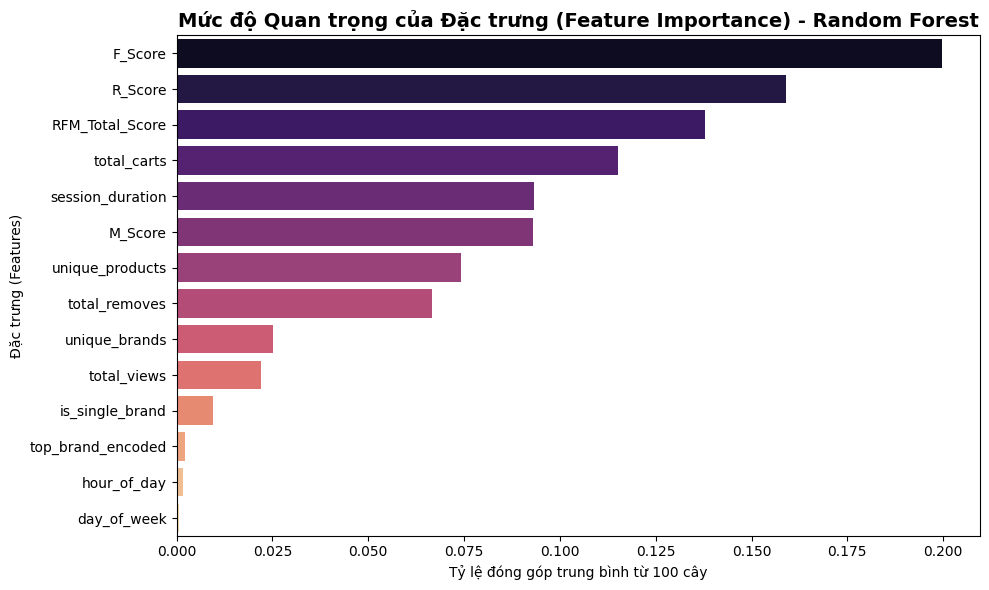

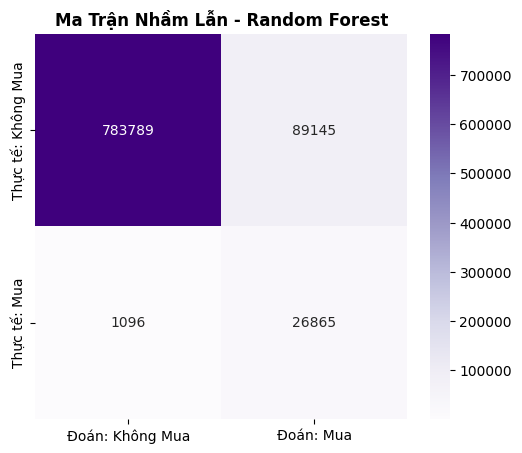

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. KHỞI TẠO VÀ HUẤN LUYỆN RANDOM FOREST


model_rf = RandomForestClassifier(
    n_estimators=100,        # Trồng 100 cây quyết định khác nhau
    max_depth=12,            # Cho phép rễ mọc sâu hơn một chút (12 tầng)
    class_weight='balanced', # Xử lý mất cân bằng lớp (khách mua ít)
    n_jobs=-1,               
    random_state=42
)

# Tiến hành huấn luyện trên tập Train (Dùng tập X_train gốc, không cần chuẩn hóa)
model_rf.fit(X_train, y_train)
print("✔️ Trồng rừng xong!")

# 2. DỰ ĐOÁN TRÊN TẬP TEST
print("Đang đưa ra dự đoán trên tập Test...\n")
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# 3. BÁO CÁO KẾT QUẢ ĐÁNH GIÁ
print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: RANDOM FOREST ")
print("=====================================================")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f" Điểm ROC-AUC Score: {roc_auc_rf:.4f}")
print("=====================================================\n")

# 4. TRỰC QUAN HÓA: MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)
importances_rf = model_rf.feature_importances_
df_importance_rf = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance_rf, x='Importance', y='Feature', palette='magma')
plt.title('Mức độ Quan trọng của Đặc trưng (Feature Importance) - Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Tỷ lệ đóng góp trung bình từ 100 cây')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

# Vẽ Ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Đoán: Không Mua', 'Đoán: Mua'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title('Ma Trận Nhầm Lẫn - Random Forest', fontweight='bold')
plt.show()

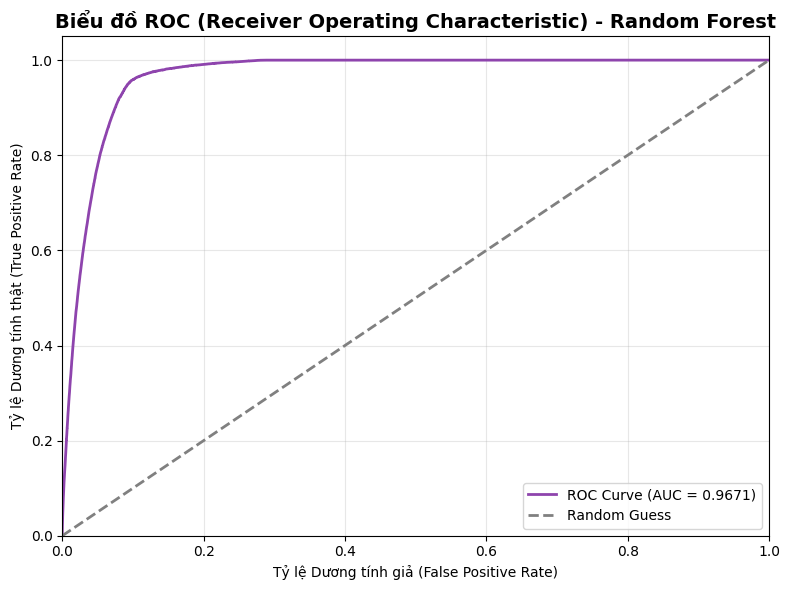

In [26]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
# Vẽ đường cong ROC cho Random Forest (Dùng màu tím cho đồng bộ với Confusion Matrix)
plt.plot(fpr_rf, tpr_rf, color='#8e44ad', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
# Vẽ đường chéo ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')

# Căn chỉnh biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Biểu đồ ROC (Receiver Operating Characteristic) - Random Forest', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from sklearn.metrics import roc_curve

# Giả sử bạn đã có y_test (nhãn thực tế) và y_prob_rf (xác suất mô hình RF dự đoán)

# 1. Hàm roc_curve tự động sinh ra 3 mảng: fpr, tpr và các ngưỡng tương ứng
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# 2. Tính mảng J (Youden's J) bằng cách trừ 2 mảng TPR và FPR
J_array = tpr - fpr

# 3. Tìm vị trí (index) của giá trị J lớn nhất trong mảng J_array
best_index = np.argmax(J_array)

# 4. Trích xuất ngưỡng tối ưu tại vị trí vừa tìm được
optimal_threshold = thresholds[best_index]

print(f"Giá trị J lớn nhất là: {J_array[best_index]:.4f}")
print(f"🔥 Ngưỡng tối ưu (Threshold) tương ứng là: {optimal_threshold:.4f}")

# -------------------------------------------------------------
# ÁP DỤNG NGƯỠNG VỪA TÌM ĐƯỢC VÀO THỰC TẾ ĐỂ PHÂN LOẠI LẠI
# -------------------------------------------------------------
# Chuyển đổi xác suất thành nhãn 0 hoặc 1 dựa trên ngưỡng optimal_threshold
y_pred_optimal = (y_prob_rf >= optimal_threshold).astype(int)

# Giờ bạn có thể in ra Báo cáo mới với ngưỡng chuẩn này
from sklearn.metrics import classification_report
print("\nBÁO CÁO KẾT QUẢ VỚI NGƯỠNG TỐI ƯU TỪ YOUDEN'S J:")
print(classification_report(y_test, y_pred_optimal))

Giá trị J lớn nhất là: 0.8594
🔥 Ngưỡng tối ưu (Threshold) tương ứng là: 0.5759

BÁO CÁO KẾT QUẢ VỚI NGƯỠNG TỐI ƯU TỪ YOUDEN'S J:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.24      0.96      0.38     27961

    accuracy                           0.90    900895
   macro avg       0.62      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895



Ngưỡng cắt tối ưu (F1-Score cao nhất): 0.8998
↳ Precision tương ứng: 0.3783
↳ Recall tương ứng: 0.6435

 BÁO CÁO LẠI: RANDOM FOREST (NGƯỠNG 0.8998) 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    872934
           1       0.38      0.64      0.48     27961

    accuracy                           0.96    900895
   macro avg       0.68      0.80      0.73    900895
weighted avg       0.97      0.96      0.96    900895



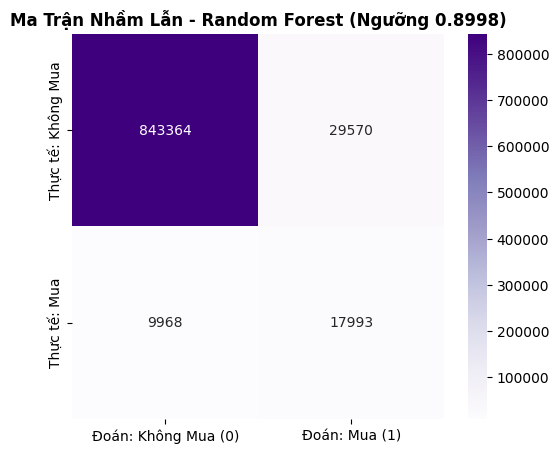

In [43]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# TÌM NGƯỠNG TỐI ƯU F1-SCORE TỪ XÁC SUẤT CÓ SẴN
# =====================================================================
# Tính toán Precision, Recall cho tất cả các ngưỡng
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Tính F1-Score và tìm vị trí cao nhất
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]

print(f"Ngưỡng cắt tối ưu (F1-Score cao nhất): {best_threshold_rf:.4f}")
print(f"↳ Precision tương ứng: {precisions[best_idx]:.4f}")
print(f"↳ Recall tương ứng: {recalls[best_idx]:.4f}\n")

# =====================================================================
# ÁP DỤNG NGƯỠNG VÀ IN BÁO CÁO MỚI
# =====================================================================
# Phân loại lại bằng ngưỡng mới
y_pred_rf_tuned = (y_prob_rf >= best_threshold_rf).astype(int)

print("=====================================================")
print(f" BÁO CÁO LẠI: RANDOM FOREST (NGƯỠNG {best_threshold_rf:.4f}) ")
print("=====================================================")
print(classification_report(y_test, y_pred_rf_tuned))

# Vẽ lại ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Random Forest (Ngưỡng {best_threshold_rf:.4f})', fontweight='bold')
plt.show()

In [12]:
joblib.dump(model_rf,'rf_model.pkl')

['rf_models.pkl']

Đang đánh thức siêu thuật toán LightGBM... 🚀
[LightGBM] [Info] Number of positive: 111845, number of negative: 3491733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.210700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 3603578, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
✔️ Huấn luyện xong! Tốc độ của LightGBM chắc chắn làm bạn bất ngờ.
Đang đưa ra dự đoán trên tập Test...

 BÁO CÁO KẾT QUẢ: LIGHTGBM (GRADIENT BOOSTING) 
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.23      0.96      0.38     27961

    accuracy                           0.90    900895
   macro avg       0.62

C:\Users\hoang\AppData\Local\Temp\ipykernel_15284\2879171061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance_lgb, x='Importance', y='Feature', palette='crest')


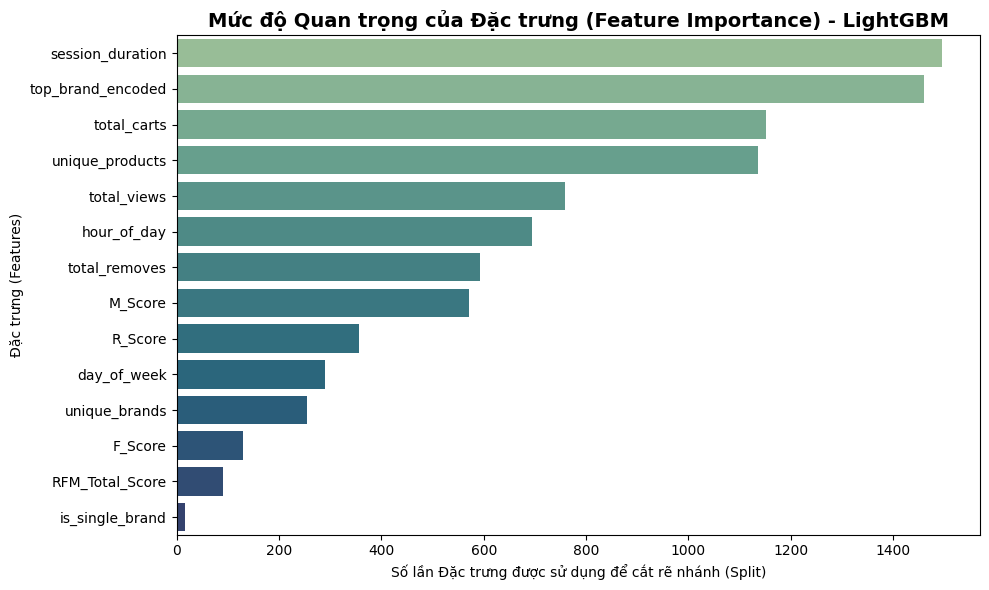

KeyError: "'Teal' is not a known colormap name"

<Figure size 600x500 with 0 Axes>

In [13]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =====================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN LIGHTGBM (BOOSTING MODEL)
# =====================================================================
print("Đang đánh thức siêu thuật toán LightGBM... 🚀")

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,          # Trồng 300 cây tuần tự liên tiếp
    learning_rate=0.05,        # Tốc độ học cẩn thận, không hấp tấp
    max_depth=10,              # Rễ cây sâu tối đa 10 tầng
    class_weight='balanced',   # Trị dứt điểm việc mất cân bằng người mua/không mua
    random_state=42,
    n_jobs=-1                  # Kích hoạt toàn bộ sức mạnh lõi CPU
)

# Huấn luyện mô hình
model_lgb.fit(X_train, y_train)
print("✔️ Huấn luyện xong! Tốc độ của LightGBM chắc chắn làm bạn bất ngờ.")

# =====================================================================
# 2. DỰ ĐOÁN TRÊN TẬP TEST
# =====================================================================
print("Đang đưa ra dự đoán trên tập Test...\n")
y_pred_lgb = model_lgb.predict(X_test)
y_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]

# =====================================================================
# 3. BÁO CÁO KẾT QUẢ
# =====================================================================
print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: LIGHTGBM (GRADIENT BOOSTING) ")
print("=====================================================")
print(classification_report(y_test, y_pred_lgb))

roc_auc_lgb = roc_auc_score(y_test, y_prob_lgb)
print(f"Điểm ROC-AUC Score: {roc_auc_lgb:.4f}")
print("=====================================================\n")

# =====================================================================
# 4. TRỰC QUAN HÓA: MỨC ĐỘ QUAN TRỌNG VÀ MA TRẬN NHẦM LẪN
# =====================================================================
importances_lgb = model_lgb.feature_importances_
df_importance_lgb = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances_lgb
}).sort_values(by='Importance', ascending=False)

# Biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance_lgb, x='Importance', y='Feature', palette='crest')
plt.title('Mức độ Quan trọng của Đặc trưng (Feature Importance) - LightGBM', fontweight='bold', fontsize=14)
plt.xlabel('Số lần Đặc trưng được sử dụng để cắt rẽ nhánh (Split)')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

# Ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Teal', 
            xticklabels=['Đoán: Không Mua', 'Đoán: Mua'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title('Ma Trận Nhầm Lẫn - LightGBM', fontweight='bold')
plt.show()

In [15]:
joblib.dump(model_lgb,'lgbmodel.pkl')

['lgbmodel.pkl']

Đang quét hàng ngàn điểm cắt để tìm ra Ngưỡng Tối Ưu nhất... 🔎

🔥 ĐÃ TÌM THẤY NGƯỠNG TỐI ƯU: 0.9101
   ↳ Dự kiến Precision sẽ tăng lên: 0.3985
   ↳ Dự kiến Recall sẽ giữ ở mức: 0.6369
   ↳ F1-Score đạt đỉnh: 0.4902

 BÁO CÁO LẠI LIGHTGBM (NGƯỠNG CẮT = 0.9101) 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    872934
           1       0.40      0.64      0.49     27961

    accuracy                           0.96    900895
   macro avg       0.69      0.80      0.73    900895
weighted avg       0.97      0.96      0.96    900895



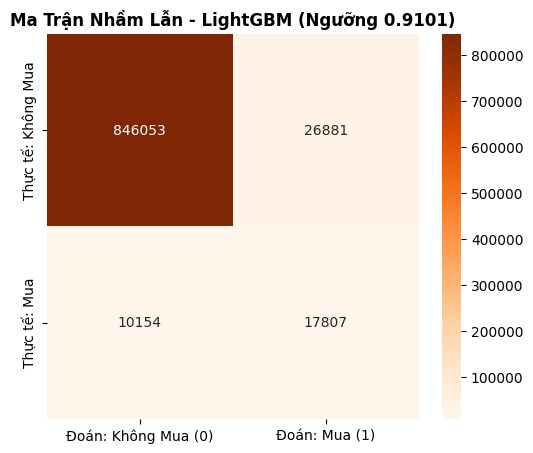

In [14]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# TÌM NGƯỠNG TỐI ƯU (OPTIMAL THRESHOLD) CHO LIGHTGBM
# =====================================================================
print("Đang quét hàng ngàn điểm cắt để tìm ra Ngưỡng Tối Ưu nhất... 🔎\n")

# 1. Tính toán Precision, Recall cho tất cả các ngưỡng
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_lgb)

# 2. Tính điểm F1-Score (Trung bình điều hòa để cân bằng Precision và Recall)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# 3. Tìm ra điểm có F1-Score cao nhất
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"🔥 ĐÃ TÌM THẤY NGƯỠNG TỐI ƯU: {best_threshold:.4f}")
print(f"   ↳ Dự kiến Precision sẽ tăng lên: {precisions[best_idx]:.4f}")
print(f"   ↳ Dự kiến Recall sẽ giữ ở mức: {recalls[best_idx]:.4f}")
print(f"   ↳ F1-Score đạt đỉnh: {f1_scores[best_idx]:.4f}\n")

# =====================================================================
# ĐÁNH GIÁ LẠI MÔ HÌNH VỚI NGƯỠNG MỚI
# =====================================================================
# Ép mô hình chỉ báo "Mua (1)" khi xác suất lớn hơn ngưỡng tối ưu vừa tìm được
y_pred_best = (y_prob_lgb >= best_threshold).astype(int)

print("=====================================================")
print(f" BÁO CÁO LẠI LIGHTGBM (NGƯỠNG CẮT = {best_threshold:.4f}) ")
print("=====================================================")
print(classification_report(y_test, y_pred_best))

# =====================================================================
# VẼ LẠI MA TRẬN NHẦM LẪN ĐỂ SO SÁNH
# =====================================================================
plt.figure(figsize=(6, 5))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - LightGBM (Ngưỡng {best_threshold:.4f})', fontweight='bold')
plt.show()

Đang thiết lập chiến thuật Ensemble theo ý tưởng của bạn... 🧩
Đang huấn luyện đội quân 15 mô hình LightGBM... ⚔️
✔️ Đã huấn luyện xong!

Đang tổng hợp phiếu bầu từ 15 mô hình để ra quyết định cuối cùng...
 BÁO CÁO KẾT QUẢ: EASY ENSEMBLE (LIGHTGBM x 15) 
🔥 Điểm ROC-AUC Score: 0.9682
🔥 Ngưỡng tối ưu tự động: 0.9156

              precision    recall  f1-score   support

           0       0.99      0.97      0.98    872934
           1       0.40      0.61      0.48     27961

    accuracy                           0.96    900895
   macro avg       0.69      0.79      0.73    900895
weighted avg       0.97      0.96      0.96    900895



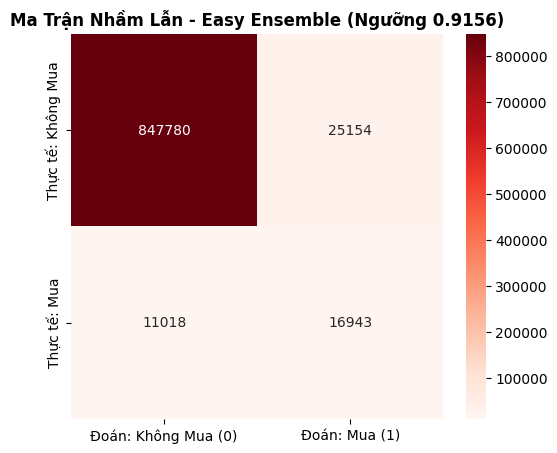

In [16]:
from imblearn.ensemble import BalancedBaggingClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 1. THIẾT LẬP CHIẾN THUẬT UNDER-BAGGING (EASY ENSEMBLE)
# =====================================================================
print("Đang thiết lập chiến thuật Ensemble theo ý tưởng của bạn... 🧩")

# Tạo mô hình lõi (Base Estimator)
# Lưu ý: Không cần class_weight='balanced' nữa, vì mỗi sub-data lúc này đã có tỷ lệ 1:1
base_model = lgb.LGBMClassifier(
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Đóng gói bằng BalancedBaggingClassifier
model_easy_ensemble = BalancedBaggingClassifier(
    estimator=base_model,
    n_estimators=15,             # Sẽ tạo ra 15 mô hình LightGBM con
    sampling_strategy='auto',    # Ép tỷ lệ 1:1 cho từng sub-data
    replacement=False,           # Lấy khách "Không mua" không trùng lặp giữa các mô hình con
    random_state=42,
    n_jobs=-1                    # Chạy song song cả 15 mô hình cho nhanh
)

# =====================================================================
# 2. HUẤN LUYỆN
# =====================================================================
print("Đang huấn luyện đội quân 15 mô hình LightGBM... ⚔️")
# Thuật toán sẽ tự động: 
# - Giữ nguyên ~22.000 khách mua ở tập Train đưa cho cả 15 mô hình.
# - Chia ~700.000 khách không mua thành 15 phần, mỗi phần nhét vào 1 mô hình.
model_easy_ensemble.fit(X_train, y_train)
print("✔️ Đã huấn luyện xong!")

# =====================================================================
# 3. DỰ ĐOÁN VÀ ĐÁNH GIÁ (KẾT HỢP VỚI TÌM NGƯỠNG TỐI ƯU)
# =====================================================================
print("\nĐang tổng hợp phiếu bầu từ 15 mô hình để ra quyết định cuối cùng...")
y_prob_ee = model_easy_ensemble.predict_proba(X_test)[:, 1]

# Tính ROC-AUC
roc_auc_ee = roc_auc_score(y_test, y_prob_ee)

# Tìm lại ngưỡng tối ưu cho mô hình mới này
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ee)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Chấm điểm với ngưỡng tối ưu
y_pred_ee_best = (y_prob_ee >= best_threshold).astype(int)

print("=====================================================")
print(f" BÁO CÁO KẾT QUẢ: EASY ENSEMBLE (LIGHTGBM x 15) ")
print("=====================================================")
print(f"🔥 Điểm ROC-AUC Score: {roc_auc_ee:.4f}")
print(f"🔥 Ngưỡng tối ưu tự động: {best_threshold:.4f}\n")
print(classification_report(y_test, y_pred_ee_best))

# =====================================================================
# 4. VẼ MA TRẬN NHẦM LẪN
# =====================================================================
plt.figure(figsize=(6, 5))
cm_ee = confusion_matrix(y_test, y_pred_ee_best)
sns.heatmap(cm_ee, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Easy Ensemble (Ngưỡng {best_threshold:.4f})', fontweight='bold')
plt.show()

In [17]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Tắt log của optuna để màn hình không bị trôi quá nhiều
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Định nghĩa không gian siêu tham số cần dò tìm
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Khởi tạo và train mô hình với bộ tham số hiện tại
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    # Dự đoán xác suất trên tập test
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Đánh giá bằng ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    return auc

# Tạo một nghiên cứu (study) tối ưu hóa
print("Đang khởi động quá trình dò tìm siêu tham số tự động bằng Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, n_jobs=1) # Thử nghiệm 20 lần

print("Đã hoàn tất quá trình tối ưu hóa!")
print(f"Giá trị ROC-AUC tốt nhất tìm được: {study.best_value:.4f}")
print("Bộ tham số tối ưu nhất:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

c:\Users\hoang\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đang khởi động quá trình dò tìm siêu tham số tự động bằng Optuna...
[LightGBM] [Info] Number of positive: 111845, number of negative: 3491733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.241015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 3603578, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 111845, number of negative: 3491733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.232383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data poin

Đang huấn luyện mô hình LightGBM cuối cùng với tham số tối ưu...
[LightGBM] [Info] Number of positive: 111845, number of negative: 3491733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.267548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 3603578, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

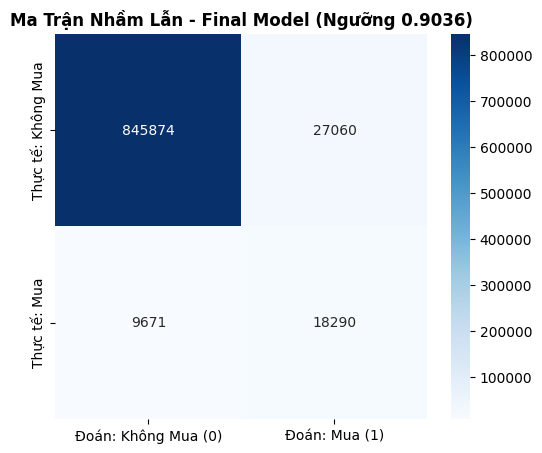

In [28]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. KHỞI TẠO MÔ HÌNH VỚI BỘ THAM SỐ TỐI ƯU TỪ OPTUNA
best_params = {
    'n_estimators': 420,
    'learning_rate': 0.02740306081373281,
    'max_depth': 13,
    'num_leaves': 186,
    'min_child_samples': 205,
    'subsample': 0.8800637751621792,
    'colsample_bytree': 0.793162578555332,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

print("Đang huấn luyện mô hình LightGBM cuối cùng với tham số tối ưu...")
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

# 2. DỰ ĐOÁN XÁC SUẤT
y_prob_final = final_model.predict_proba(X_test)[:, 1]
roc_auc_final = roc_auc_score(y_test, y_prob_final)

# 3. TÌM NGƯỠNG TỐI ƯU (THRESHOLD TUNING)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_final)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold_final = thresholds[best_idx]

# 4. ĐÁNH GIÁ VỚI NGƯỠNG TỐI ƯU
y_pred_final = (y_prob_final >= best_threshold_final).astype(int)

print("=====================================================")
print(" BÁO CÁO KẾT QUẢ CUỐI CÙNG: LIGHTGBM (OPTUNA TUNED) ")
print("=====================================================")
print(f"Điểm ROC-AUC Score: {roc_auc_final:.4f}")
print(f"Ngưỡng cắt tối ưu: {best_threshold_final:.4f}\n")
print(classification_report(y_test, y_pred_final))

# 5. VẼ MA TRẬN NHẦM LẪN
plt.figure(figsize=(6, 5))
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Đoán: Không Mua (0)', 'Đoán: Mua (1)'],
            yticklabels=['Thực tế: Không Mua', 'Thực tế: Mua'])
plt.title(f'Ma Trận Nhầm Lẫn - Final Model (Ngưỡng {best_threshold_final:.4f})', fontweight='bold')
plt.show()

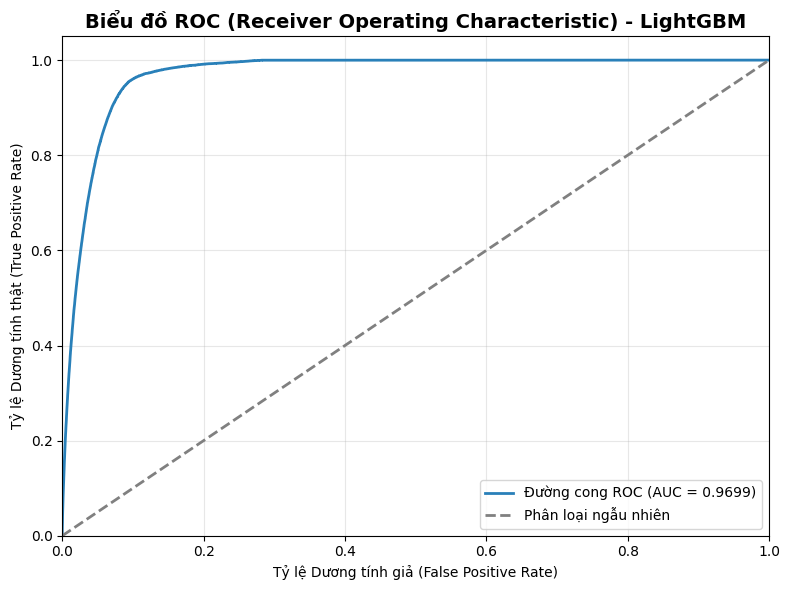

In [34]:
fpr_final, tpr_final, roc_thresholds = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(8, 6))
# Vẽ đường cong phân loại của LightGBM
plt.plot(fpr_final, tpr_final, color='#2980b9', lw=2, label=f'Đường cong ROC (AUC = {roc_auc_final:.4f})')
# Vẽ đường biểu diễn khả năng phân loại ngẫu nhiên
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Phân loại ngẫu nhiên')

# Căn chỉnh hiển thị không gian đồ thị
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Biểu đồ ROC (Receiver Operating Characteristic) - LightGBM', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from sklearn.metrics import roc_curve, classification_report

# =====================================================================
# TÍNH TOÁN NGƯỠNG TỐI ƯU DỰA TRÊN YOUDEN'S J STATISTIC
# =====================================================================

# 1. Trích xuất FPR, TPR và các ngưỡng từ hàm roc_curve
# (Thay y_prob_final bằng biến chứa xác suất mô hình của bạn nếu cần)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

# 2. Tính toán mảng chỉ số Youden's J (J = TPR - FPR)
J_scores = tpr - fpr

# 3. Tìm vị trí (index) của điểm có chỉ số J lớn nhất
best_idx = np.argmax(J_scores)

# 4. Trích xuất Ngưỡng tối ưu và giá trị J tương ứng tại vị trí đó
best_threshold = thresholds[best_idx]
best_J = J_scores[best_idx]

print("=====================================================")
print(" KẾT QUẢ TÌM NGƯỠNG TỐI ƯU (YOUDEN'S J) ")
print("=====================================================")
print(f"Giá trị J lớn nhất đạt được: {best_J:.4f}")
print(f"Ngưỡng quyết định tối ưu tương ứng: {best_threshold:.4f}")
print(f"   (Tại ngưỡng này -> TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f})")
print("=====================================================\n")

# =====================================================================
# ÁP DỤNG NGƯỠNG ĐỂ XEM BÁO CÁO PHÂN LOẠI MỚI
# =====================================================================

# Phân loại lại: Xác suất >= ngưỡng tối ưu thì gán 1, ngược lại gán 0
y_pred_optimal = (y_prob_final >= best_threshold).astype(int)

print(f"BÁO CÁO KẾT QUẢ VỚI NGƯỠNG {best_threshold:.4f}:")
print(classification_report(y_test, y_pred_optimal))

 KẾT QUẢ TÌM NGƯỠNG TỐI ƯU (YOUDEN'S J) 
Giá trị J lớn nhất đạt được: 0.8607
Ngưỡng quyết định tối ưu tương ứng: 0.5250
   (Tại ngưỡng này -> TPR: 0.9563, FPR: 0.0956)

BÁO CÁO KẾT QUẢ VỚI NGƯỠNG 0.5250:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.24      0.96      0.39     27961

    accuracy                           0.91    900895
   macro avg       0.62      0.93      0.67    900895
weighted avg       0.97      0.91      0.93    900895



In [19]:
import joblib

# 1. Đóng gói mô hình, ngưỡng tối ưu và danh sách các biến vào một dictionary
model_package = {
    'model': final_model,                      # Mô hình LightGBM sau khi tối ưu bằng Optuna
    'optimal_threshold': best_threshold_final, # Ngưỡng cắt tối ưu (~0.91) giúp đạt Precision 0.40
    'features': X_train.columns.tolist()       # Danh sách 16 biến đầu vào để đối chiếu sau này
}

# 2. Xuất dữ liệu này thành một file duy nhất có đuôi .pkl
joblib.dump(model_package, 'LightGBM_Final_Model.pkl')

print("Đã lưu mô hình thành công!")
print("Tên file được tạo ra trong thư mục hiện tại: LightGBM_Final_Model.pkl")

Đã lưu mô hình thành công!
Tên file được tạo ra trong thư mục hiện tại: LightGBM_Final_Model.pkl


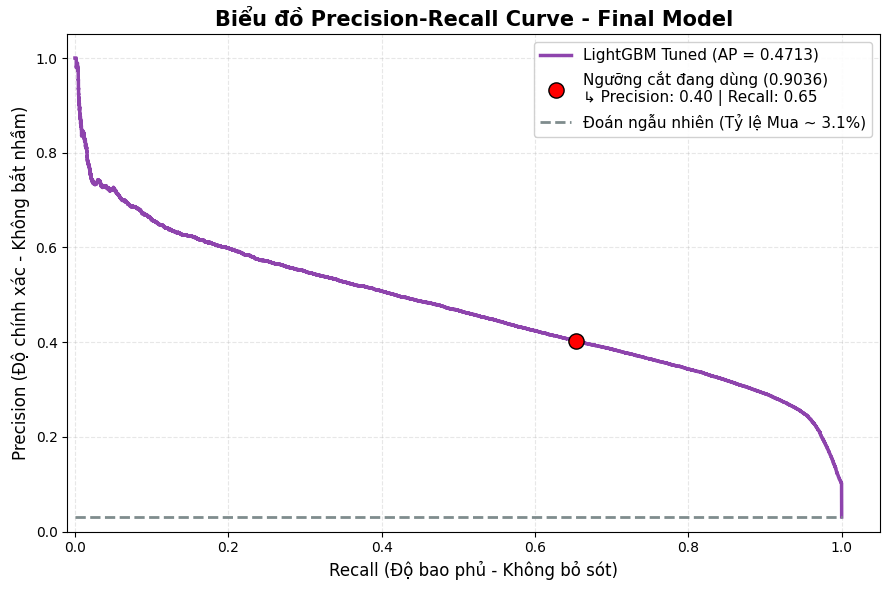

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Tính toán các điểm Precision, Recall và điểm Average Precision (AP)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_final)
ap_score = average_precision_score(y_test, y_prob_final)

# 2. Tìm vị trí của ngưỡng tối ưu trên đường cong để vẽ điểm nhấn (Marker)
# best_threshold_final là biến bạn đã lưu ở bước chạy Optuna trước đó
best_idx = np.argmin(np.abs(thresholds - best_threshold_final))

# 3. Tiến hành vẽ biểu đồ
plt.figure(figsize=(9, 6))

# Vẽ đường cong PR chính
plt.plot(recalls, precisions, color='#8e44ad', lw=2.5, 
         label=f'LightGBM Tuned (AP = {ap_score:.4f})')

# Đánh dấu "Hồng tâm" - Điểm tối ưu mà chúng ta đã chọn
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, zorder=5, 
            edgecolor='black',
            label=f'Ngưỡng cắt đang dùng ({best_threshold_final:.4f})\n'
                  f'↳ Precision: {precisions[best_idx]:.2f} | Recall: {recalls[best_idx]:.2f}')

# Vẽ đường Baseline (Tỷ lệ đoán bừa - Tương đương tỷ lệ khách mua tự nhiên ~3%)
baseline = sum(y_test) / len(y_test)
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='#7f8c8d', lw=2, 
         label=f'Đoán ngẫu nhiên (Tỷ lệ Mua ~ {baseline*100:.1f}%)')

# Trang trí
plt.xlim([-0.01, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Độ bao phủ - Không bỏ sót)', fontsize=12)
plt.ylabel('Precision (Độ chính xác - Không bắt nhầm)', fontsize=12)
plt.title('Biểu đồ Precision-Recall Curve - Final Model', fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# Hiển thị
plt.show()